# Failure Structure and Robustness in Syscall Intrusion Detection

Performance averages alone cannot explain deployment risk in intrusion detection. A detector can post strong global metrics while failing systematically on particular attack mechanisms. This stage therefore examines error structure at multiple resolutions to identify where and why decisions break.

The analysis focuses on family-specific vulnerability, scenario concentration of mistakes, sequence-length effects, and stability under controlled perturbations. Together, these views provide a more faithful picture of operational reliability than aggregate scores alone.

## Construction of a Unified Error Corpus

All prediction artefacts are merged with protocol metadata to produce a single test-level frame containing labels, scores, model decisions, attack family, scenario, and sequence length. This unified table is the analytical substrate for every subsequent decomposition.

The merge step is methodologically important: without consistent trace-level alignment, subgroup conclusions can be distorted by indexing drift across artefacts.

In [6]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import torch

PROJECT_ROOT = Path.cwd().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

from src.datasets import SyscallSequenceDataset, make_dataloader
from src.evaluate import evaluate_lstm_classifier
from src.lstm_model import LSTMClassifier
from src.metrics import compute_binary_metrics
from src.utils import PROCESSED_ROOT, RESULTS_ROOT, ensure_dir

sns.set_theme(style='whitegrid', context='talk')

tables_dir = ensure_dir(RESULTS_ROOT / 'tables')
fig_dir = ensure_dir(PROJECT_ROOT / 'reports' / 'figures')

baseline_results_path = tables_dir / 'baseline_results_all_splits.csv'
lstm_results_path = tables_dir / 'lstm_ablation_results.csv'
baseline_pred_path = tables_dir / 'predictions_baselines_test.csv'
lstm_pred_path = tables_dir / 'predictions_lstm_test.csv'
lstm_best_path = tables_dir / 'lstm_best_run_summary.csv'

meta_path = PROJECT_ROOT / 'data' / 'metadata' / 'adfa_sample_index_protocol_a.csv'
proc_index_path = PROCESSED_ROOT / 'protocol_a_main_ml1231_dualview_v1' / 'adfa_processed_index.parquet'
seq_post_path = PROCESSED_ROOT / 'protocol_a_main_ml1231_dualview_v1' / 'adfa_sequences_post.npy'
seq_pre_path = PROCESSED_ROOT / 'protocol_a_main_ml1231_dualview_v1' / 'adfa_sequences_pre.npy'

required_files = [
    baseline_results_path,
    lstm_results_path,
    baseline_pred_path,
    lstm_pred_path,
    lstm_best_path,
    meta_path,
    proc_index_path,
    seq_post_path,
    seq_pre_path,
]
missing = [str(p) for p in required_files if not p.exists()]
if missing:
    raise FileNotFoundError('Missing required inputs. Run notebooks 03/04 first. Missing: ' + '; '.join(missing))

baseline_results = pd.read_csv(baseline_results_path)
lstm_results = pd.read_csv(lstm_results_path)
baseline_pred = pd.read_csv(baseline_pred_path)
lstm_pred = pd.read_csv(lstm_pred_path)
lstm_best = pd.read_csv(lstm_best_path)
meta_df = pd.read_csv(meta_path)
proc_index = pd.read_parquet(proc_index_path)

key_cols = ['trace_id', 'split', 'length', 'attack_family', 'attack_scenario', 'label_binary']
test_meta = meta_df.merge(
    proc_index[key_cols],
    on='trace_id',
    how='inner',
    suffixes=('_meta', '_proc'),
)
for col in ['split', 'length', 'attack_family', 'attack_scenario', 'label_binary']:
    proc_col = f'{col}_proc'
    meta_col = f'{col}_meta'
    if proc_col in test_meta.columns:
        test_meta[col] = test_meta[proc_col]
    elif meta_col in test_meta.columns:
        test_meta[col] = test_meta[meta_col]

test_meta = test_meta[test_meta['split'] == 'test'].copy()

print('Loaded baseline rows:', len(baseline_results), '| LSTM rows:', len(lstm_results))
print('Test traces:', len(test_meta))

Loaded baseline rows: 10 | LSTM rows: 28
Test traces: 1286


## Comparative Performance at the Test Operating Point

The consolidated comparison shows that no model is uniformly dominant across all objectives. The recurrent model offers a stronger precision-recall compromise at its tuned threshold, while Random Forest variants preserve superior ranking behaviour and lower miss rates in several settings.

This pattern underscores a central principle of security evaluation: model choice should be aligned with cost asymmetry between missed attacks and alert overload, rather than driven by a single headline metric.

In [7]:
baseline_test = baseline_results[baseline_results['split'] == 'test'].copy()
lstm_test = lstm_results[lstm_results['split'] == 'test'].copy()

compare_cols = ['model', 'algorithm', 'feature_set', 'split', 'accuracy', 'precision', 'recall', 'f1', 'roc_auc', 'pr_auc', 'fpr', 'fnr']
final_compare = pd.concat([
    baseline_test[compare_cols],
    lstm_test[compare_cols],
], ignore_index=True).sort_values('f1', ascending=False).reset_index(drop=True)

final_compare_path = tables_dir / 'final_baseline_vs_lstm.csv'
final_compare.to_csv(final_compare_path, index=False)

display(final_compare)
print('Saved:', final_compare_path)

,model,algorithm,feature_set,split,accuracy,precision,recall,f1,roc_auc,pr_auc,fpr,fnr
0,lstm_post_e128_h128_d0.1,lstm,sequence_post,test,0.838258,0.434251,0.860606,0.577236,0.889822,0.454867,0.165031,0.139394
1,rf_tfidf,rf,tfidf,test,0.809487,0.396373,0.927273,0.555354,0.928714,0.641494,0.207850,0.072727
2,rf_bow,rf,bow,test,0.814152,0.400538,0.903030,0.554935,0.931052,0.676517,0.198930,0.096970
3,lstm_post_e64_h128_d0.3,lstm,sequence_post,test,0.821928,0.406977,0.848485,0.550098,0.858054,0.366912,0.181980,0.151515
4,lstm_post_e128_h128_d0.3,lstm,sequence_post,test,0.811820,0.394521,0.872727,0.543396,0.867037,0.476913,0.197145,0.127273
5,lstm_post_e128_h128_d0.5,lstm,sequence_post,test,0.823484,0.405488,0.806061,0.539554,0.865772,0.437251,0.173952,0.193939
6,lstm_post_e128_h256_d0.1,lstm,sequence_post,test,0.812597,0.391429,0.830303,0.532039,0.886062,0.449672,0.190009,0.169697
7,lstm_post_e128_h256_d0.3,lstm,sequence_post,test,0.826594,0.404605,0.745455,0.524520,0.842613,0.339698,0.161463,0.254545
8,lstm_post_e64_h128_d0.1,lstm,sequence_post,test,0.814152,0.388554,0.781818,0.519115,0.863152,0.391327,0.181088,0.218182
9,lstm_post_e64_h256_d0.5,lstm,sequence_post,test,0.812597,0.386905,0.787879,0.518962,0.851058,0.364465,0.183764,0.212121


Saved: C:\Users\223114186\Desktop\System_Call_Based_Intrusion_Detection\syscall-anomaly-detection\results\tables\final_baseline_vs_lstm.csv


## Family and Scenario Localisation of Errors

Error localisation reveals that the dominant failure mode is concentrated in behaviourally ambiguous families, not distributed uniformly. Adduser remains particularly difficult because its syscall-number profile overlaps benign administrative activity, reducing separability for both frequency and sequence models.

Scenario-level aggregation further shows that generalisation degradation is context-sensitive. This indicates that failures are linked to distributional shift in execution patterns rather than random instability.

In [8]:
best_baseline_name = baseline_test.sort_values('f1', ascending=False).iloc[0]['model']
if 'model' in lstm_best.columns:
    best_lstm_name = lstm_best.iloc[0]['model']
elif 'run_name' in lstm_best.columns:
    best_lstm_name = lstm_best.iloc[0]['run_name']
else:
    raise ValueError(f'No model identifier column in lstm_best: {list(lstm_best.columns)}')

pred_baseline_best = baseline_pred[baseline_pred['model'] == best_baseline_name].copy()
pred_lstm_best = lstm_pred[lstm_pred['model'] == best_lstm_name].copy()

def enrich_preds(pred_df, model_name):
    m = pred_df.merge(
        test_meta[['trace_id', 'attack_family', 'attack_scenario', 'length', 'label_binary']],
        on='trace_id',
        how='left',
    )
    m['model'] = model_name
    m['error_type'] = 'correct'
    m.loc[(m['y_true'] == 0) & (m['y_pred'] == 1), 'error_type'] = 'false_positive'
    m.loc[(m['y_true'] == 1) & (m['y_pred'] == 0), 'error_type'] = 'false_negative'
    return m

pred_b = enrich_preds(pred_baseline_best, best_baseline_name)
pred_l = enrich_preds(pred_lstm_best, best_lstm_name)

all_pred = pd.concat([pred_b, pred_l], ignore_index=True)

fp_df = all_pred[all_pred['error_type'] == 'false_positive'].copy()
fn_df = all_pred[all_pred['error_type'] == 'false_negative'].copy()

fp_path = tables_dir / 'error_analysis_false_positives.csv'
fn_path = tables_dir / 'error_analysis_false_negatives.csv'
fp_df.to_csv(fp_path, index=False)
fn_df.to_csv(fn_path, index=False)

scenario_err = (
    all_pred.groupby(['model', 'attack_scenario'])
    .apply(lambda g: pd.Series({
        'count': len(g),
        'error_rate': float((g['y_true'] != g['y_pred']).mean()),
        'fpr': float((((g['y_true'] == 0) & (g['y_pred'] == 1)).sum()) / max(1, (g['y_true'] == 0).sum())),
        'fnr': float((((g['y_true'] == 1) & (g['y_pred'] == 0)).sum()) / max(1, (g['y_true'] == 1).sum())),
    }))
    .reset_index()
    .sort_values(['model', 'error_rate'], ascending=[True, False])
)
scenario_err_path = tables_dir / 'error_analysis_by_attack_scenario.csv'
scenario_err.to_csv(scenario_err_path, index=False)

family_err = (
    all_pred.groupby(['model', 'attack_family'])
    .apply(lambda g: pd.Series({
        'count': len(g),
        'error_rate': float((g['y_true'] != g['y_pred']).mean()),
    }))
    .reset_index()
    .sort_values(['model', 'error_rate'], ascending=[True, False])
)
family_err_path = tables_dir / 'error_analysis_by_attack_family.csv'
family_err.to_csv(family_err_path, index=False)

length_bins = pd.qcut(all_pred['length'], q=5, duplicates='drop')
len_err = (
    all_pred.assign(length_bin=length_bins)
    .groupby(['model', 'length_bin'])
    .apply(lambda g: pd.Series({
        'count': len(g),
        'error_rate': float((g['y_true'] != g['y_pred']).mean()),
        'mean_length': float(g['length'].mean()),
    }))
    .reset_index()
)
len_err['length_bin'] = len_err['length_bin'].astype(str)
len_err_path = tables_dir / 'error_analysis_by_length_bin.csv'
len_err.to_csv(len_err_path, index=False)

hard_attacks = (
    all_pred[all_pred['y_true'] == 1]
    .groupby(['model', 'attack_family'])
    .apply(lambda g: pd.Series({'recall_attack_family': float((g['y_pred'] == 1).mean()), 'count': len(g)}))
    .reset_index()
    .sort_values(['model', 'recall_attack_family'])
)
hard_attacks_path = tables_dir / 'error_analysis_hardest_attacks.csv'
hard_attacks.to_csv(hard_attacks_path, index=False)

print('Best baseline:', best_baseline_name)
print('Best LSTM:', best_lstm_name)
print('Saved:', fp_path)
print('Saved:', fn_path)
print('Saved:', scenario_err_path)
print('Saved:', family_err_path)
print('Saved:', len_err_path)
print('Saved:', hard_attacks_path)
display(hard_attacks.head(12))

Best baseline: rf_tfidf
Best LSTM: lstm_post_e128_h128_d0.1
Saved: C:\Users\223114186\Desktop\System_Call_Based_Intrusion_Detection\syscall-anomaly-detection\results\tables\error_analysis_false_positives.csv
Saved: C:\Users\223114186\Desktop\System_Call_Based_Intrusion_Detection\syscall-anomaly-detection\results\tables\error_analysis_false_negatives.csv
Saved: C:\Users\223114186\Desktop\System_Call_Based_Intrusion_Detection\syscall-anomaly-detection\results\tables\error_analysis_by_attack_scenario.csv
Saved: C:\Users\223114186\Desktop\System_Call_Based_Intrusion_Detection\syscall-anomaly-detection\results\tables\error_analysis_by_attack_family.csv
Saved: C:\Users\223114186\Desktop\System_Call_Based_Intrusion_Detection\syscall-anomaly-detection\results\tables\error_analysis_by_length_bin.csv
Saved: C:\Users\223114186\Desktop\System_Call_Based_Intrusion_Detection\syscall-anomaly-detection\results\tables\error_analysis_hardest_attacks.csv


,model,attack_family,recall_attack_family,count
0,lstm_post_e128_h128_d0.1,Adduser,0.571429,28.0
5,lstm_post_e128_h128_d0.1,Web_Shell,0.807692,26.0
4,lstm_post_e128_h128_d0.1,Meterpreter,0.833333,12.0
1,lstm_post_e128_h128_d0.1,Hydra_FTP,0.942857,35.0
3,lstm_post_e128_h128_d0.1,Java_Meterpreter,0.961538,26.0
2,lstm_post_e128_h128_d0.1,Hydra_SSH,0.973684,38.0
6,rf_tfidf,Adduser,0.642857,28.0
9,rf_tfidf,Java_Meterpreter,0.961538,26.0
8,rf_tfidf,Hydra_SSH,0.973684,38.0
7,rf_tfidf,Hydra_FTP,1.000000,35.0


## Class Prevalence and Decision Trade-Offs

Imbalance effects appear clearly in the precision-recall geometry. Models tuned for stronger attack recovery tend to increase false alarms, whereas conservative thresholds reduce alert volume at the cost of additional missed attacks.

This trade-off is structural, not accidental. It reflects the low prior probability of attacks in the evaluation corpus and should be managed through explicit operating-policy design rather than post hoc metric selection.

In [9]:
imbalance_rows = []
for model_name, g in all_pred.groupby('model'):
    prevalence_attack = float((g['y_true'] == 1).mean())
    prevalence_normal = float((g['y_true'] == 0).mean())

    attack_subset = g[g['y_true'] == 1]
    normal_subset = g[g['y_true'] == 0]

    recall_attack = float((attack_subset['y_pred'] == 1).mean()) if len(attack_subset) else np.nan
    precision_attack = float(((g['y_true'] == 1) & (g['y_pred'] == 1)).sum() / max(1, (g['y_pred'] == 1).sum()))
    specificity_normal = float((normal_subset['y_pred'] == 0).mean()) if len(normal_subset) else np.nan

    imbalance_rows.append({
        'model': model_name,
        'prevalence_attack': prevalence_attack,
        'prevalence_normal': prevalence_normal,
        'recall_attack': recall_attack,
        'precision_attack': precision_attack,
        'specificity_normal': specificity_normal,
    })

imbalance_df = pd.DataFrame(imbalance_rows).sort_values('recall_attack', ascending=False)
imbalance_path = tables_dir / 'error_analysis_imbalance_impact.csv'
imbalance_df.to_csv(imbalance_path, index=False)

display(imbalance_df)
print('Saved:', imbalance_path)

,model,prevalence_attack,prevalence_normal,recall_attack,precision_attack,specificity_normal
1,rf_tfidf,0.128305,0.871695,0.927273,0.396373,0.792150
0,lstm_post_e128_h128_d0.1,0.128305,0.871695,0.860606,0.434251,0.834969


Saved: C:\Users\223114186\Desktop\System_Call_Based_Intrusion_Detection\syscall-anomaly-detection\results\tables\error_analysis_imbalance_impact.csv


## Stability of Sequential Decisions Under Input Perturbation

Robustness is evaluated through controlled deletion and substitution perturbations applied to test traces. The objective is to measure whether mild corruption produces disproportionate decision changes, which would indicate brittle representations.

The measured deltas remain small and prediction stability remains high, suggesting that the recurrent model distributes evidence across the sequence instead of relying on isolated positions. This behaviour is valuable in practical environments where trace capture may be imperfect.

In [ ]:
best_row = lstm_best.iloc[0]
best_ckpt = Path(str(best_row['checkpoint_path']))
if not best_ckpt.is_absolute():
    best_ckpt = PROJECT_ROOT / best_ckpt
if not best_ckpt.exists():
    raise FileNotFoundError(f'Checkpoint not found: {best_ckpt}. Re-run notebook 04 or scripts/run_lstm_ablation.py to regenerate it.')
if 'view' in lstm_best.columns:
    best_view = str(best_row['view'])
elif 'feature_set' in lstm_best.columns:
    best_view = str(best_row['feature_set']).replace('sequence_', '')
else:
    run_name = str(best_row.get('run_name', ''))
    best_view = 'pre' if 'pre' in run_name else 'post'

if best_view == 'post':
    seq_arr = np.load(seq_post_path)
    eff_len_col = 'len_after_post'
else:
    seq_arr = np.load(seq_pre_path)
    eff_len_col = 'len_after_pre'

full_df = proc_index.reset_index(drop=True).copy()
if eff_len_col not in full_df.columns:
    raise ValueError(f'Missing required length column: {eff_len_col}')

# Rebuild variable-length sequences exactly like notebook 04 split builder.
eff_lengths = full_df[eff_len_col].fillna(0).astype(int).tolist()
encoded_trimmed = []
for arr, eff_len in zip(seq_arr, eff_lengths):
    k = max(1, int(eff_len))
    encoded_trimmed.append(arr[:k].tolist())
full_df['encoded'] = encoded_trimmed

test_df = full_df[full_df['split'] == 'test'].reset_index(drop=True)

vocab_size = int(seq_arr.max() + 1)
pad_value = 0
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Récupérer les paramètres du meilleur run (avec les nouvelles ablations)
bidirectional = bool(best_row.get('bidirectional', True))
use_attention = bool(best_row.get('use_attention', True))
num_layers = int(best_row.get('num_layers', 2))

model = LSTMClassifier(
    vocab_size=vocab_size,
    embedding_dim=int(best_row['embedding_dim']),
    hidden_size=int(best_row['hidden_size']),
    num_layers=num_layers,
    dropout=float(best_row['dropout']),
    padding_idx=pad_value,
    bidirectional=bidirectional,
    use_attention=use_attention,
)
checkpoint = torch.load(best_ckpt, map_location=device)
if isinstance(checkpoint, dict) and 'model_state_dict' in checkpoint:
    model.load_state_dict(checkpoint['model_state_dict'])
else:
    model.load_state_dict(checkpoint)
model.to(device)
model.eval()

rng = np.random.default_rng(42)

def perturb_delete_local(seq, delete_ratio=0.1):
    if len(seq) < 5:
        return seq
    n_del = max(1, int(len(seq) * delete_ratio))
    start = int(rng.integers(0, max(1, len(seq) - n_del)))
    return seq[:start] + seq[start + n_del:]

def perturb_substitute(seq, substitute_ratio=0.05):
    if len(seq) == 0:
        return seq
    n_sub = max(1, int(len(seq) * substitute_ratio))
    idxs = rng.choice(len(seq), size=min(n_sub, len(seq)), replace=False)
    out = list(seq)
    for idx in idxs:
        out[idx] = int(rng.integers(1, vocab_size))
    return out

def eval_sequences(seqs, labels, trace_ids):
    ds = SyscallSequenceDataset(seqs, labels, sample_ids=trace_ids, return_metadata=False)
    dl = make_dataloader(ds, batch_size=64, shuffle=False, pad_value=pad_value, sort_by_length=False, num_workers=0)
    return evaluate_lstm_classifier(model, dl, device=device)

base_eval = eval_sequences(
    test_df['encoded'].tolist(),
    test_df['label_binary'].astype(int).tolist(),
    test_df['trace_id'].astype(str).tolist(),
)

delete_eval = eval_sequences(
    [perturb_delete_local(s, delete_ratio=0.1) for s in test_df['encoded'].tolist()],
    test_df['label_binary'].astype(int).tolist(),
    test_df['trace_id'].astype(str).tolist(),
)

noise_eval = eval_sequences(
    [perturb_substitute(s, substitute_ratio=0.05) for s in test_df['encoded'].tolist()],
    test_df['label_binary'].astype(int).tolist(),
    test_df['trace_id'].astype(str).tolist(),
)

robust_df = pd.DataFrame([
    {'condition': 'clean', **base_eval['metrics']},
    {'condition': 'delete_local_10pct', **delete_eval['metrics']},
    {'condition': 'substitute_5pct', **noise_eval['metrics']},
])
robust_df['delta_f1_vs_clean'] = robust_df['f1'] - float(robust_df.loc[robust_df['condition'] == 'clean', 'f1'].iloc[0])
robust_df['delta_auc_vs_clean'] = robust_df['roc_auc'] - float(robust_df.loc[robust_df['condition'] == 'clean', 'roc_auc'].iloc[0])
robust_path = tables_dir / 'robustness_stability_lstm.csv'
robust_df.to_csv(robust_path, index=False)

stability = pd.DataFrame({
    'trace_id': test_df['trace_id'].astype(str).tolist(),
    'clean_pred': base_eval['y_pred'],
    'delete_pred': delete_eval['y_pred'],
    'noise_pred': noise_eval['y_pred'],
})
stability['stable_delete'] = stability['clean_pred'] == stability['delete_pred']
stability['stable_noise'] = stability['clean_pred'] == stability['noise_pred']
stability['stable_both'] = stability['stable_delete'] & stability['stable_noise']
stability_path = tables_dir / 'robustness_prediction_stability.csv'
stability.to_csv(stability_path, index=False)

stability_summary = pd.DataFrame([
    {'metric': 'stable_delete_rate', 'value': float(stability['stable_delete'].mean())},
    {'metric': 'stable_noise_rate', 'value': float(stability['stable_noise'].mean())},
    {'metric': 'stable_both_rate', 'value': float(stability['stable_both'].mean())},
])
stability_summary_path = tables_dir / 'robustness_prediction_stability_summary.csv'
stability_summary.to_csv(stability_summary_path, index=False)

display(robust_df)
display(stability_summary)
print('Best view used:', best_view)
print('Saved:', robust_path)
print('Saved:', stability_path)
print('Saved:', stability_summary_path)

,condition,accuracy,precision,recall,f1,fpr,fnr,tp,tn,fp,fn,roc_auc,pr_auc,delta_f1_vs_clean,delta_auc_vs_clean
0,clean,0.812597,0.399471,0.915152,0.556169,0.202498,0.084848,151.0,894.0,227.0,14.0,0.889822,0.454867,0.000000,0.000000
1,delete_local_10pct,0.808709,0.394256,0.915152,0.551095,0.206958,0.084848,151.0,889.0,232.0,14.0,0.887208,0.450088,-0.005075,-0.002614
2,substitute_5pct,0.810264,0.394102,0.890909,0.546468,0.201606,0.109091,147.0,895.0,226.0,18.0,0.885416,0.444211,-0.009701,-0.004406


,metric,value
0,stable_delete_rate,0.989891
1,stable_noise_rate,0.980560
2,stable_both_rate,0.972784


Best view used: post
Saved: C:\Users\223114186\Desktop\System_Call_Based_Intrusion_Detection\syscall-anomaly-detection\results\tables\robustness_stability_lstm.csv
Saved: C:\Users\223114186\Desktop\System_Call_Based_Intrusion_Detection\syscall-anomaly-detection\results\tables\robustness_prediction_stability.csv
Saved: C:\Users\223114186\Desktop\System_Call_Based_Intrusion_Detection\syscall-anomaly-detection\results\tables\robustness_prediction_stability_summary.csv


## Synthesis of Error Dynamics and Practical Implications

The evidence converges on a consistent interpretation. Most residual risk originates from intrinsically ambiguous behavioural regions of the feature space, especially attacks whose syscall-number traces resemble legitimate administration. This limitation is shared across model families, which indicates a representational ceiling rather than a purely architectural one.

At the same time, recurrent modelling contributes practical value through improved operating-point balance and strong perturbation stability. A production strategy can therefore combine robust frequency baselines for broad ranking strength with calibrated sequential models where false-alarm control and decision stability are priorities.

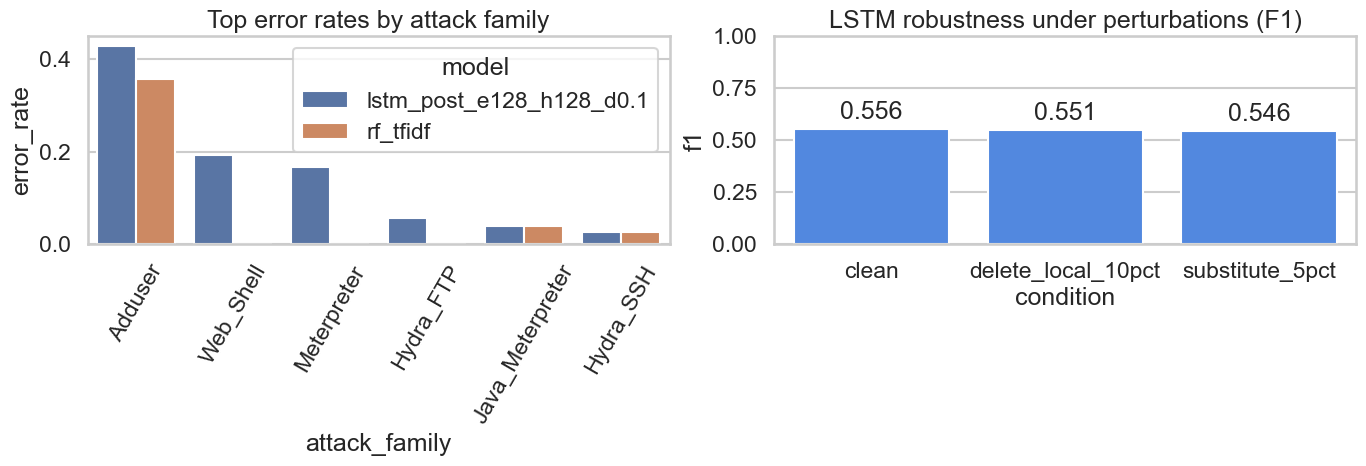

Saved: c:\Users\223114186\Desktop\System_Call_Based_Intrusion_Detection\syscall-anomaly-detection\reports\figures\error_analysis_and_robustness_summary.png
Saved: C:\Users\223114186\Desktop\System_Call_Based_Intrusion_Detection\syscall-anomaly-detection\results\tables\model_limitations_notes.csv


In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

plot_family = family_err.sort_values('error_rate', ascending=False).head(12)
sns.barplot(data=plot_family, x='attack_family', y='error_rate', hue='model', ax=axes[0])
axes[0].set_title('Top error rates by attack family')
axes[0].tick_params(axis='x', rotation=60)

sns.barplot(data=robust_df, x='condition', y='f1', ax=axes[1], color='#3B82F6')
axes[1].set_title('LSTM robustness under perturbations (F1)')
axes[1].set_ylim(0, 1)
for container in axes[1].containers:
    axes[1].bar_label(container, fmt='%.3f', padding=3)

fig.tight_layout()
fig_path = fig_dir / 'error_analysis_and_robustness_summary.png'
fig.savefig(fig_path, dpi=150)
plt.show()
plt.close(fig)

limitations = pd.DataFrame([
    {'topic': 'distribution_shift', 'note': 'Perturbations are synthetic and may not represent all real attack drifts.'},
    {'topic': 'sequence_editing', 'note': 'Deletion/substitution does not model insertion or reordering explicitly.'},
    {'topic': 'single_dataset', 'note': 'Conclusions are currently limited to ADFA-LD.'},
])
limitations_path = tables_dir / 'model_limitations_notes.csv'
limitations.to_csv(limitations_path, index=False)

print('Saved:', fig_path)
print('Saved:', limitations_path)